# Purpose of Model

# Customer Churn and Revenue Prediction Model

## Purpose

This model is designed to:

- Identify which customers are likely to churn over the next quarter in order to enable targeted marketing campaigns that aim to prevent churn.

### Importance of Churn Prevention

Customer churn represents a significant cost to businesses — not only through lost revenue but also through the increased expense of acquiring new customers. This model helps mitigate churn by predicting which customers are at risk of not purchasing withint the next three months which we have defined as churning.

With this insight, marketing can automate targetted discount on products which the customer has previously purchase to improve retention rates. Additionally, the model estimates each customer’s expected spend over the same period, enhancing the cost-effectiveness of customer retention efforts.

### Model Development & Approach

The model was built using transactional data from a UK-based e-commerce store and follows a two-stage regression approach:

1. **Churn Prediction (Logistic Regression)**  
   Estimates the probability of a customer churning within the next three months.

2. **Future Spend Prediction (Linear Regression)**  
   For customers predicted to remain active, forecasts their total spending over the same period.

Currently, the model uses **Recency, Frequency, and Monetary (RFM)** features for its predictions. Future iterations will incorporate additional features following the initial deployment.

By leveraging this model, the marketing team can better identify high-value customers at risk of churning and improve revenue forecasting across the existing customer base.

# Establishing the Environment
Sci Kit learn will be the package used for the ML modelling and SeaBorne, Matplotlib for the graphing. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from datetime import datetime
from dateutil.relativedelta import relativedelta
from scipy import stats
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Loading data 
The transactional data use is from 01/12/2010 and 09/12/2011 and it is from a UK-based and registered non-store online retailer. The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

In [2]:
transactions = pd.read_csv('Ecommerce_data.csv', encoding='latin')
transactions.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 8:26,3.39,17850.0,United Kingdom


# Data Exploration / Analysis and cleaning 
### It will be used to get a better understanding of the business and any problems with the data

In [3]:
transactions.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [4]:
# taking out any incorrect data entry
transactions=transactions.loc[transactions['UnitPrice']>0]
transactions=transactions.loc[transactions['Quantity']>0]


In [5]:
# formatting the date column
transactions['InvoiceDate']=pd.to_datetime(transactions['InvoiceDate'])
transactions['month'] = transactions['InvoiceDate'].dt.month
transactions['year'] = transactions['InvoiceDate'].dt.year
transactions.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,month,year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2010


In [6]:
# Roughly a years worth of data has been gathered
transactions['InvoiceDate']=pd.to_datetime(transactions['InvoiceDate'])
print(transactions['InvoiceDate'].min())
print(transactions['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


## Sales 
Around 700-800k for January - August and then increase to 1 million for September to December 

         Date  month  year        Sales
0  2010-12-01     12  2010   823746.140
1  2011-01-01      1  2011   691364.560
2  2011-02-01      2  2011   523631.890
3  2011-03-01      3  2011   717639.360
4  2011-04-01      4  2011   537808.621
5  2011-05-01      5  2011   770536.020
6  2011-06-01      6  2011   761739.900
7  2011-07-01      7  2011   719221.191
8  2011-08-01      8  2011   759138.380
9  2011-09-01      9  2011  1058590.172
10 2011-10-01     10  2011  1154979.300
11 2011-11-01     11  2011  1509496.330
12 2011-12-01     12  2011   638792.680


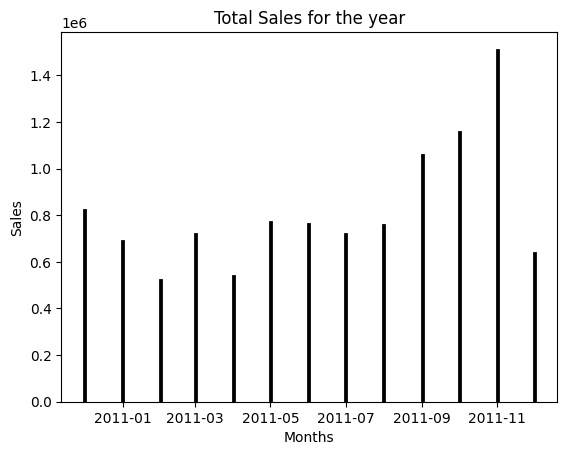

In [7]:
# Sales accross the year
transactions['Sales']=transactions['Quantity']*transactions['UnitPrice']

total_monthly_sales=transactions.groupby(['month','year']).agg({'Sales':'sum'})
total_monthly_sales=total_monthly_sales.reset_index()
total_monthly_sales['Date'] = pd.to_datetime(total_monthly_sales[['year', 'month']].assign(day=1))
total_monthly_sales=total_monthly_sales.groupby(['Date']).agg('sum').reset_index()

sum_monthly_sales=total_monthly_sales[['Sales','Date']]
print(total_monthly_sales)


plt.bar(sum_monthly_sales['Date'],sum_monthly_sales['Sales'],linewidth=2.0,edgecolor='black')
plt.title('Total Sales for the year')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.show()

# Customers
There are 4338 unique customers and a total of 397884 transactions with Customer IDs and 132220 without CustomerID. There are a total of 530,104 transactions


In [8]:
print("Unique IDs:", transactions['CustomerID'].nunique())
print("Transactions with ID's:",transactions['CustomerID'].count())
print("Transactions without IDs:",(transactions['CustomerID'].isnull()).sum())
Unique_Customer= transactions['CustomerID'].nunique()



Unique IDs: 4338
Transactions with ID's: 397884
Transactions without IDs: 132220


# Revenue 
### There is a large tail on the distribution of revenue. With the majority of customers spending less then $10,000 at the retailer and a handful that spend between 100,000 - 250,000

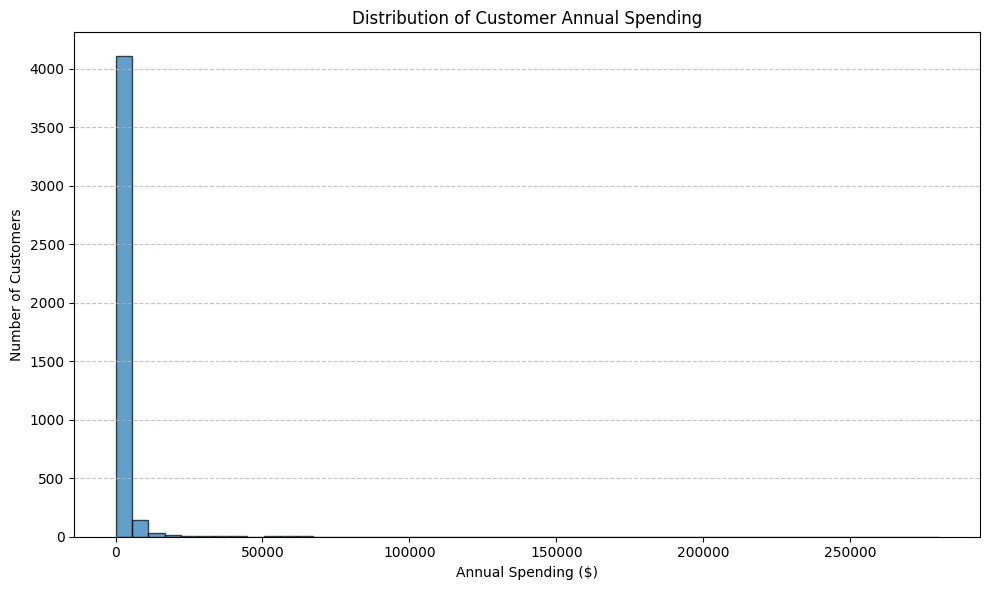

In [9]:
cust_trans=transactions[['Sales','CustomerID']].groupby(['CustomerID']).agg('sum').sort_values('Sales')
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(cust_trans, bins=50, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Annual Spending ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Annual Spending')

# Add grid for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()

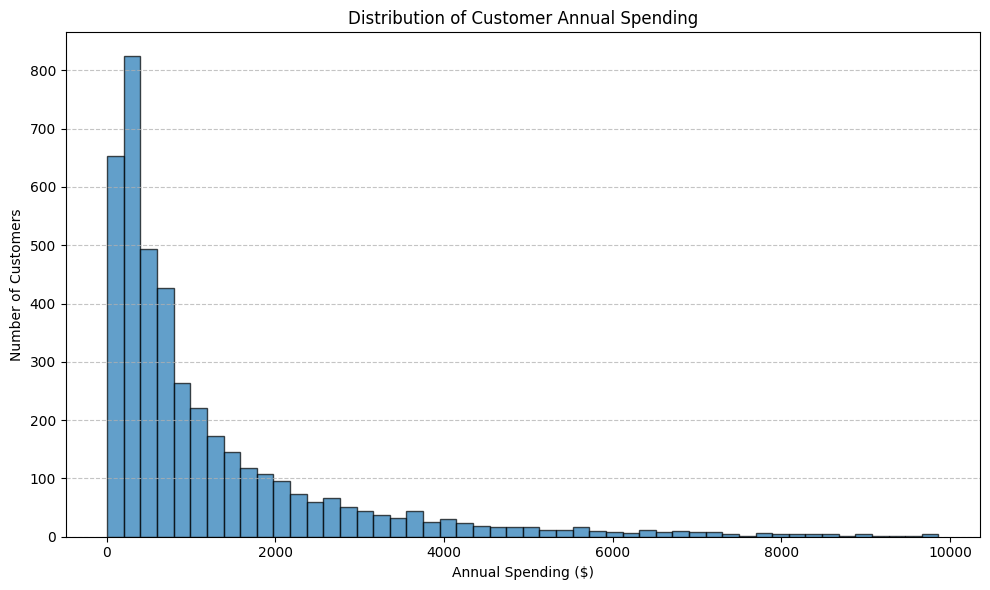

In [10]:
cust_trans_filt=cust_trans.loc[cust_trans['Sales']<10000]
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(cust_trans_filt, bins=50, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Annual Spending ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Annual Spending')

# Add grid for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()

In [11]:
transactions=transactions.loc[transactions['Sales']<10000]

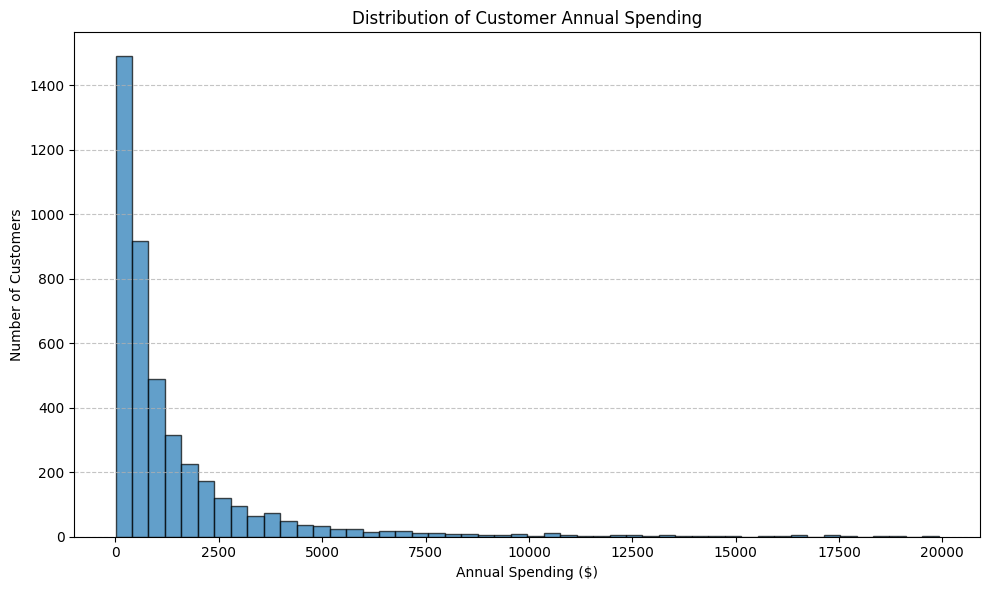

In [12]:


# cust_trans=cust_trans.reset_index()
cust_spec=cust_trans.loc[cust_trans['Sales']<20000]
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(cust_spec, bins=50, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Annual Spending ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Annual Spending')

# Add grid for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()

# Products
World War gliders by far are the most sold item at the store.

In [13]:
# Item quantity sold
# largest quantity of items sold
item_quant=transactions.groupby(['Description']).agg({'Quantity':'sum'}).reset_index()
item_quant=item_quant.sort_values('Quantity')
top_sales=item_quant.tail(10)
print(top_sales)

                             Description  Quantity
2334  PACK OF 60 PINK PAISLEY CAKE CASES     24854
2302          PACK OF 12 LONDON TISSUES      26135
2106             MINI PAINT SET VINTAGE      26633
2739                  RABBIT NIGHT LIGHT     30788
2336     PACK OF 72 RETROSPOT CAKE CASES     36419
227        ASSORTED COLOUR BIRD ORNAMENT     36461
2679                      POPCORN HOLDER     36761
3842  WHITE HANGING HEART T-LIGHT HOLDER     37891
1815             JUMBO BAG RED RETROSPOT     48474
3932   WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047


# Transaction by country 
The Vast majority of transactions come from UK (91.5%)

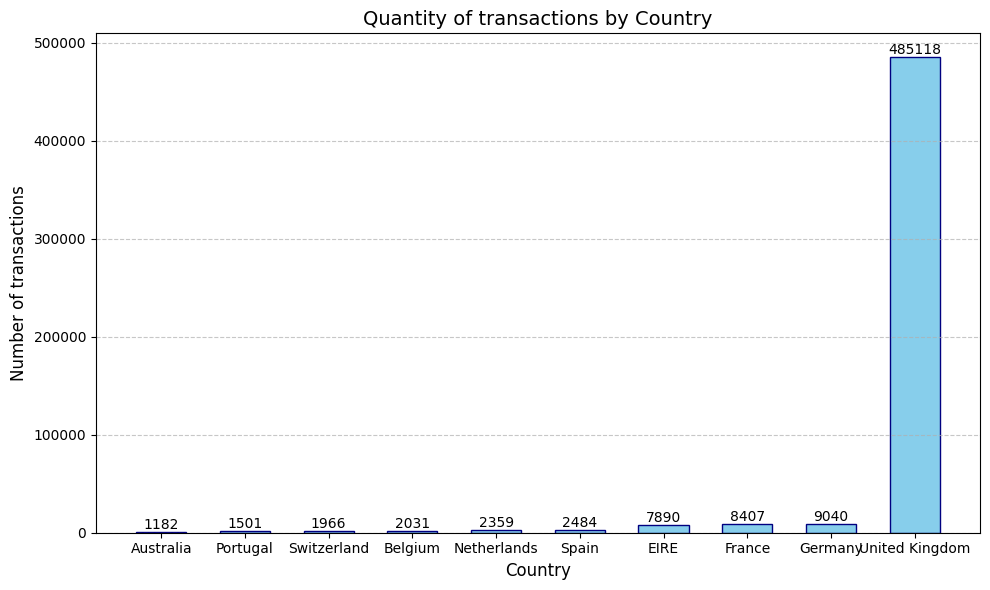

In [14]:
trans_by_country=transactions.groupby(['Country']).agg({'Country':'count'})
trans_by_country=trans_by_country.rename(columns={'Country':'Quantity'})
trans_ranks_count=trans_by_country.sort_values('Quantity').tail(10).reset_index()


plt.figure(figsize=(10, 6))
bars = plt.bar(height=trans_ranks_count['Quantity'],x=trans_ranks_count['Country'], color='skyblue', edgecolor='navy', width=0.6)

# Add title and labels
plt.title('Quantity of transactions by Country', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of transactions', fontsize=12)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height}', ha='center', va='bottom')

# Add grid lines for the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Customize appearance
plt.tight_layout()
plt.show()

# Using the ML algorithm to understand the expected LTV of customers

Lifetime Value of customers is the future value of the customer, which can be seperated into

- will they Churn? (Classification)
 
- what is the expected customer spend of the customer? (Regression)

2 different models will be used to predict both these variables. This knowledge will be used to prioritise marketing spend into "saving customers", allowing promotional spend to be less then the expected future spend of customers.

# Step 1 - Defining the problems and the parameters of the model
a) Define Churn:
We will define churn as a customer not having purchased a good for 90 days

b) Seperate the historical (Training Data) and the testing data as to be able to quantify the accuracy of the model






In [15]:
n_days = 90
max_date=transactions['InvoiceDate'].max()
cutoff= max_date-pd.to_timedelta(n_days, unit="d")
 # train-test Split- temporal out df relates to the actual amount of expenditure in the next 90 days after the target date
print(cutoff)

2011-09-10 12:50:00


## Develop targets: 
Using the cutoff to seperate the data with only customer ids which are present in the training data being available in the test data, creating targets for the algorithm

In [16]:
temporal_in_df=transactions[transactions['InvoiceDate']< cutoff]
temporal_out_df=transactions[transactions['InvoiceDate'] >=cutoff].query('CustomerID in @temporal_in_df.CustomerID')
targets=temporal_out_df[['CustomerID','Sales']].groupby(['CustomerID']).sum().rename({'Sales':'Sales_90'},axis=1).assign(sales_90_flag=1)

# Step 2: Create  Features 
RFM will be used as the basic features for the ML model as they have been proven to be important data points in predicting future customer behaviour [^1]

Recency- when was the last time they made a purchase in days

Frequency- How many times did they purchase during the period

Monetary Values- What was the total monetary value they spent during the time and what is the average value of the the transactions

As RFM have known relationships between the future value of a customer we will use this as the basis for the ML. In the future we can develop further features which increase the relationship between historical data and the future value.

In [17]:
max_date=temporal_in_df['InvoiceDate'].max()
recency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').apply(lambda x: int((x['InvoiceDate'].max()-max_date)/pd.to_timedelta(1,"day"))).to_frame()
recency_features_df=recency_features_df.rename(columns={0:'Recency'})
recency_features_df.head()

C:\Users\As-Pro\AppData\Local\Temp\ipykernel_15288\2772036709.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').apply(lambda x: int((x['InvoiceDate'].max()-max_date)/pd.to_timedelta(1,"day"))).to_frame()


,Recency
CustomerID,
12347.0,-38
12348.0,-157
12350.0,-219
12352.0,-171
12353.0,-113


## Create Recency Features
- The last time they purchased minus the maximum amount of days during the period under analysis

max_date=temporal_in_df['InvoiceDate'].max()
recency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').apply(lambda x: int((x['InvoiceDate'].max()-max_date)/pd.to_timedelta(1,"day"))).to_frame()
recency_features_df=recency_features_df.rename(columns={0:'Recency'})
recency_features_df.head()

# Majority of customers ordered less than a year ago

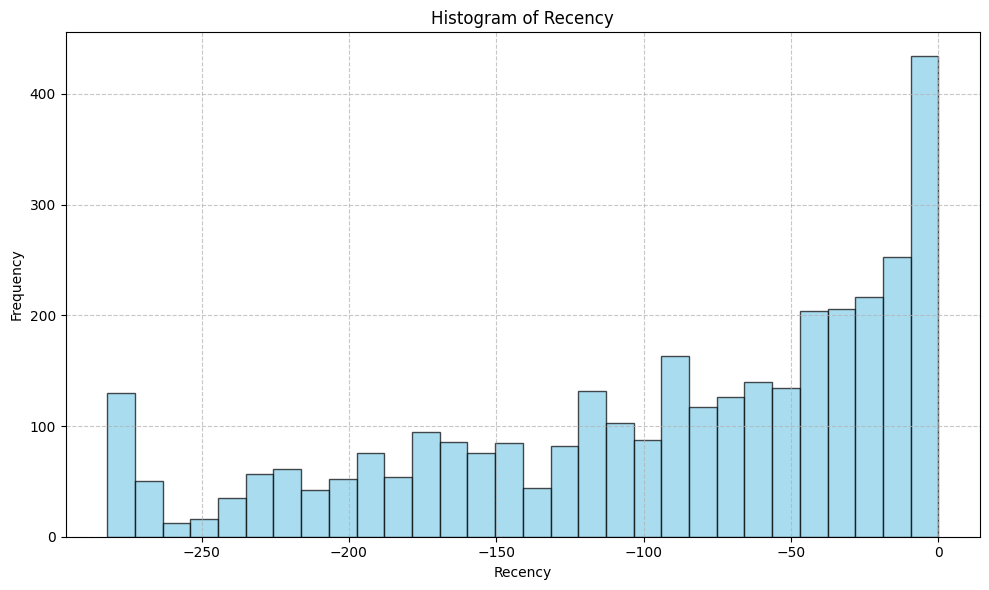

In [18]:
column_name = 'Recency'  # Replace with your actual column name

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(recency_features_df[column_name], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel(column_name)
plt.ylabel('Frequency')
plt.title(f'Histogram of {column_name}')

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

# Create Frequency Features
- The number of times in which they purchased over the period under analysis

In [19]:
frequency_features_df=temporal_in_df[['CustomerID','InvoiceDate']].groupby('CustomerID').count()
frequency_features_df=frequency_features_df.rename(columns={'InvoiceDate':'Frequency'})
frequency_features_df.head()

,Frequency
CustomerID,
12347.0,124
12348.0,28
12350.0,17
12352.0,38
12353.0,4


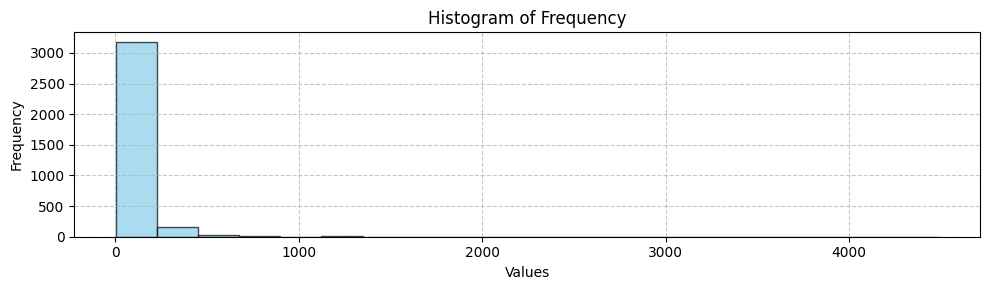

In [20]:
# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=len(frequency_features_df.columns), figsize=(10, 3*len(frequency_features_df.columns)))

# If there's only one column, axes will not be an array
if len(frequency_features_df.columns) == 1:
    axes = [axes]

# Plot histogram for each column
for i, column in enumerate(frequency_features_df.columns):
    axes[i].hist(frequency_features_df[column], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel('Values')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [21]:
frequency_features_df[frequency_features_df['Frequency']>1500]


,Frequency
CustomerID,
12748.0,2040
14606.0,2038
14911.0,2958
15311.0,1725
17841.0,4490


# Create Monetary Value Features
- The average sale of each transactions and the total sales during the period of historical sales


In [22]:
monetary_features=temporal_in_df.groupby(['CustomerID']).agg({'Sales':['sum','mean']}).set_axis(['sales_value_sum','sales_values_mean'],axis=1)
print(monetary_features)

            sales_value_sum  sales_values_mean
CustomerID                                    
12347.0             2790.86          22.506935
12348.0             1487.24          53.115714
12350.0              334.40          19.670588
12352.0             1561.81          41.100263
12353.0               89.00          22.250000
...                     ...                ...
18280.0              180.60          18.060000
18281.0               80.82          11.545714
18282.0              100.21          14.315714
18283.0             1120.67           2.507092
18287.0              765.28          26.388966

[3369 rows x 2 columns]


In [23]:
monetary_features

,sales_value_sum,sales_values_mean
CustomerID,,
12347.0,2790.86,22.506935
12348.0,1487.24,53.115714
12350.0,334.40,19.670588
12352.0,1561.81,41.100263
12353.0,89.00,22.250000
...,...,...
18280.0,180.60,18.060000
18281.0,80.82,11.545714
18282.0,100.21,14.315714


# Create A month off Cutoff as a feature
This will be an added feature which will help develop the future probability of LTV. As a customer who has purchased within the last 14 days, is a greater 

In [24]:
cut_off_m= cutoff-pd.to_timedelta(30,unit="d")

sales_last_month=temporal_in_df.query('InvoiceDate >= @cut_off_m')\
[['CustomerID','Sales']].drop_duplicates()\
.groupby('CustomerID')\
.sum()\
.set_axis(['sales_last_month'],axis=1).fillna(0)


array([[<Axes: title={'center': 'sales_last_month'}>]], dtype=object)

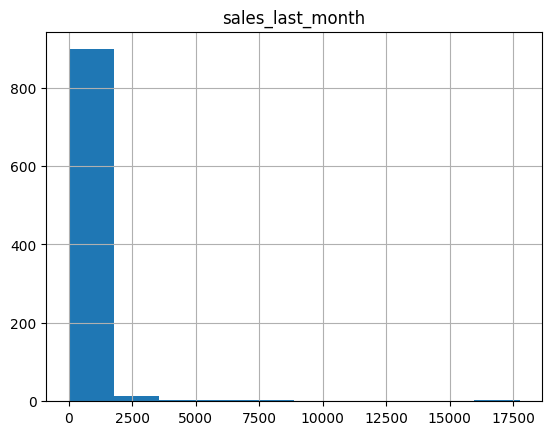

In [25]:
sales_last_month.hist()

# Concatinate all the features into the singular dataframe and merge in the targets

In [26]:
features=pd.concat([recency_features_df, frequency_features_df, monetary_features,sales_last_month],axis=1)
features['sales_last_month']=features['sales_last_month'].fillna(0)
features=features.merge(targets,how='left',left_index=True,right_index=True)
features['Sales_90']=features['Sales_90'].fillna(0)
features['sales_90_flag']=features['sales_90_flag'].fillna(0)
features.head()

,Recency,Frequency,sales_value_sum,sales_values_mean,sales_last_month,Sales_90,sales_90_flag
CustomerID,,,,,,,
12347.0,-38,124,2790.86,22.506935,0.0,1519.14,1.0
12348.0,-157,28,1487.24,53.115714,0.0,310.00,1.0
12350.0,-219,17,334.40,19.670588,0.0,0.00,0.0
12352.0,-171,38,1561.81,41.100263,0.0,944.23,1.0
12353.0,-113,4,89.00,22.250000,0.0,0.00,0.0


# Regression model to predict the value of a customer

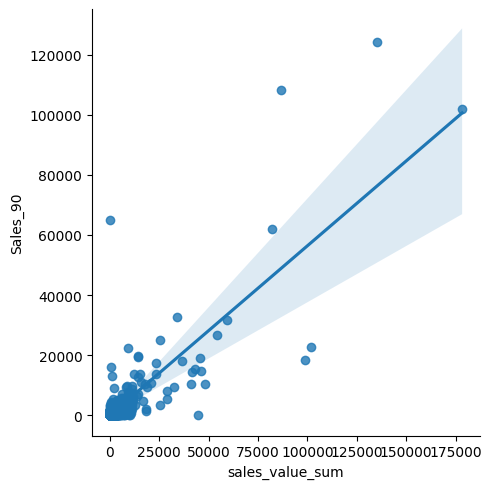

In [27]:

sns.lmplot(x='sales_value_sum',y='Sales_90',data=features)
plt.show()


The hypothesis is that customers who have a greater recency in there last purchase will have a higher probability of not churning, as there will be a lower chance of external factors effecting customers demand for product such as bankruptcy change, change of catalogue or changing supplier

The Boxplot shows that those customers who didnt churn (made a purchase in the last 90 days) had made a purchase on average more recently then those who did churn. This is an indicator that recency is a good indicator for whether a customer more will churn or not. This is furthered by the one way ANOVA test with a p-value of pretty much zero, indicating a strong relationship between the average recency and whether they have churned or not

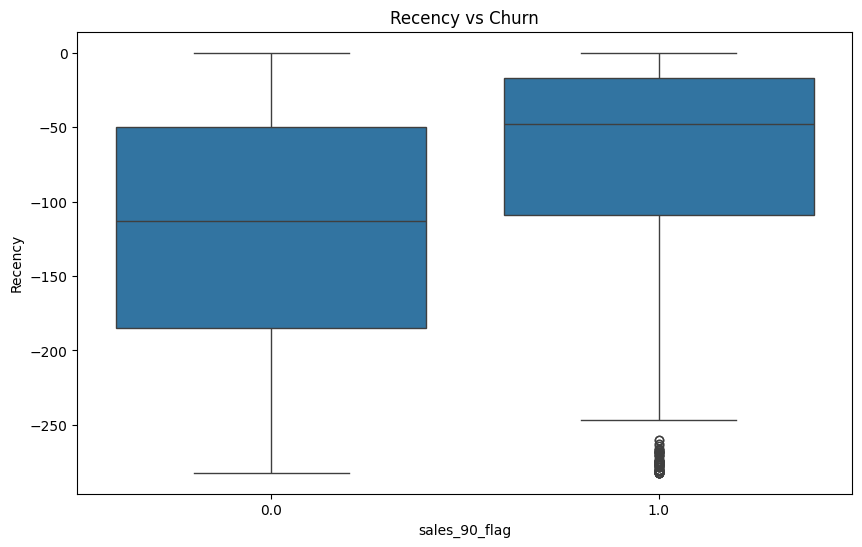

In [28]:

# Create box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='sales_90_flag', y='Recency', data=features)
plt.title('Recency vs Churn')
plt.show()

In [29]:
# Assuming df has your data with 'category_col' and 'continuous_col'
categories = features['sales_90_flag'].unique()
data_by_category = [features[features['sales_90_flag'] == cat]['Recency'] for cat in categories]

# One-way ANOVA
f_stat, p_value = stats.f_oneway(*data_by_category)
print(f"F-statistic: {f_stat}, p-value: {p_value}")

F-statistic: 345.745224339899, p-value: 1.529374578448938e-73


Testing the relationship between frequency and churn. With the hypthosis of greater frequency forming more of a habit and a greater dependency on the supplier. 

The boxplot below shows customer who havent churned have a higher median frequency then those that have churned. The p-value of the Frequency and the 90 day chis very low as well, which means there is a very high probability that the frequency and feature are related.

In [30]:
# Assuming df has your data with 'category_col' and 'continuous_col'
categories = features['sales_90_flag'].unique()
data_by_category = [features[features['sales_90_flag'] == cat]['Frequency'] for cat in categories]

# One-way ANOVA
f_stat, p_value = stats.f_oneway(*data_by_category)
print(f"F-statistic: {f_stat}, p-value: {p_value}")

F-statistic: 164.45847006933926, p-value: 8.603762648546917e-37


## Splitting the features data set into training and testing data with 20-80 split

In [31]:
x=features.drop(columns=['Sales_90','sales_90_flag'])
y=features[['Sales_90']]

x=x.loc[x.index != 14646.0]
y=y.loc[y.index != 14646.0]

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=100,test_size=.2)

### RMSE is calculated as the total error observed and devided by the number of datapoints and then square rooted 

In [32]:

model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)



In [33]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

RMSE: 1464.3575341054873


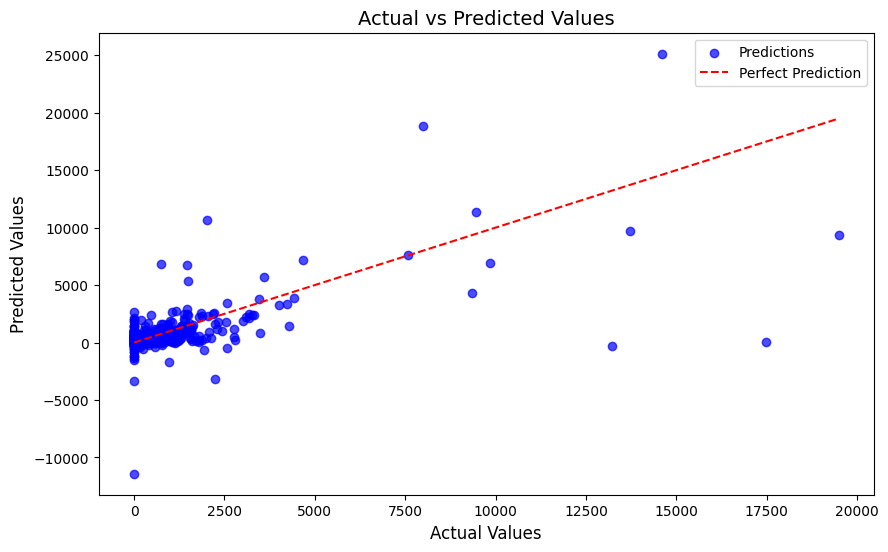

In [34]:
# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label='Predictions')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', 
         linestyle='--', 
         label='Perfect Prediction')

# Plot styling
plt.title('Actual vs Predicted Values', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()

In [35]:
predicted_quarterly_revenue=int(y_pred.sum())
print(predicted_quarterly_revenue)

412265


# Logistical regression for the classification of of Churn, not Churn 

In [36]:

x=features.drop(columns=['Sales_90','sales_90_flag'])
i=features[['sales_90_flag']]



i_train,i_test,x_train,x_test=train_test_split(i,x,random_state=100,test_size=.2)

print(i.shape)
print(x.shape)

(3369, 1)
(3369, 5)


In [37]:
logreg = LogisticRegression(random_state=16)
logreg.fit(x_train,i_train)
logreg_pred = logreg.predict(x_test)

target_names = ['churned', 'did not churn']
print(classification_report(i_test, logreg_pred, target_names=target_names))

               precision    recall  f1-score   support

      churned       0.63      0.57      0.60       290
did not churn       0.70      0.75      0.72       384

     accuracy                           0.67       674
    macro avg       0.66      0.66      0.66       674
 weighted avg       0.67      0.67      0.67       674



C:\Users\As-Pro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [38]:
logreg_liblinear = LogisticRegression(solver='liblinear',random_state=42)
logreg_liblinear.fit(x_train,i_train)
lib_pred = logreg_liblinear.predict(x_test)


target_names = ['churned', 'did not churn']
print(classification_report(i_test, lib_pred, target_names=target_names))

               precision    recall  f1-score   support

      churned       0.61      0.61      0.61       290
did not churn       0.70      0.70      0.70       384

     accuracy                           0.66       674
    macro avg       0.66      0.66      0.66       674
 weighted avg       0.66      0.66      0.66       674



C:\Users\As-Pro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [39]:
lr_elastic = LogisticRegression(solver='saga', random_state=42)
lr_elastic.fit(x_train,i_train)
elasticnet = lr_elastic.predict(x_test)
target_names = ['churned', 'did not churn']
print(classification_report(i_test, elasticnet, target_names=target_names))

C:\Users\As-Pro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


               precision    recall  f1-score   support

      churned       0.67      0.11      0.18       290
did not churn       0.59      0.96      0.73       384

     accuracy                           0.59       674
    macro avg       0.63      0.53      0.46       674
 weighted avg       0.62      0.59      0.49       674



C:\Users\As-Pro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [40]:
lr_newton = LogisticRegression(solver='newton-cg', random_state=42)
lr_newton.fit(x_train,i_train)
newt_pred = lr_newton.predict(x_test)
target_names = ['churned', 'did not churn']
print(classification_report(i_test, newt_pred, target_names=target_names))


C:\Users\As-Pro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


               precision    recall  f1-score   support

      churned       0.63      0.57      0.60       290
did not churn       0.70      0.75      0.72       384

     accuracy                           0.67       674
    macro avg       0.66      0.66      0.66       674
 weighted avg       0.67      0.67      0.67       674



In [41]:
# Using the sag solver
lr_sag = LogisticRegression(solver='sag', random_state=42)
lr_sag.fit(x_train, i_train)
lr_sag=lr_sag.predict(x_test)
target_names = ['churned', 'did not churn']
print(classification_report(i_test, lr_sag, target_names=target_names))

C:\Users\As-Pro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


               precision    recall  f1-score   support

      churned       0.68      0.26      0.38       290
did not churn       0.62      0.91      0.74       384

     accuracy                           0.63       674
    macro avg       0.65      0.58      0.56       674
 weighted avg       0.64      0.63      0.58       674



C:\Users\As-Pro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


The major cost for the a company is a customer churning, which hadnt been predicted to churn. Therefore the true benefit of the model is based on the recall which are the true positives, which is calculated to be at 75%. As true negatives only have a small cost associated with the intervention.

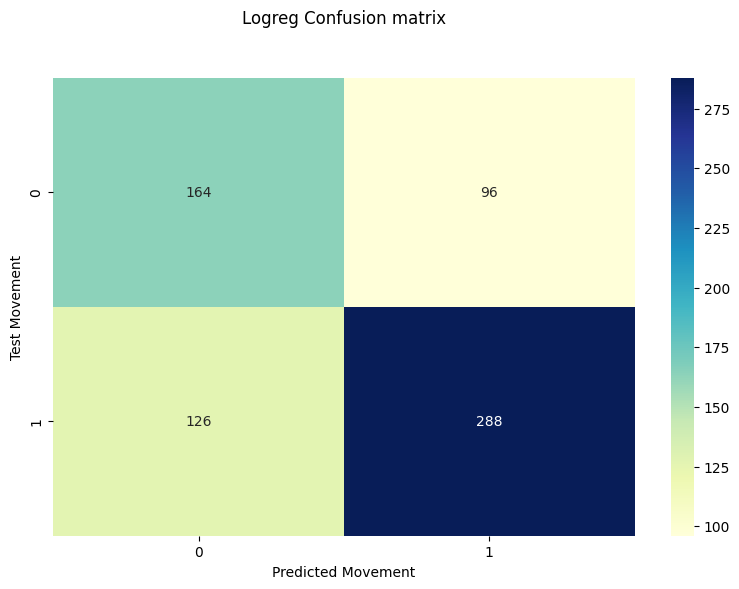

Confusion Matrix:
[[164  96]
 [126 288]]


In [42]:
# Generate the confusion matrix
cnf_matrix = confusion_matrix(logreg_pred, i_test)

# Define class names
class_names = ['Not Churned', 'Churned']  # name of classes

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Set tick marks and labels
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')

# Adjust axis labels
ax.xaxis.set_label_position("bottom")

# Add labels and title
plt.title('Logreg Confusion matrix', y=1.1)
plt.ylabel('Test Movement')
plt.xlabel('Predicted Movement')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# Print confusion matrix values for reference
print("Confusion Matrix:")
print(cnf_matrix)


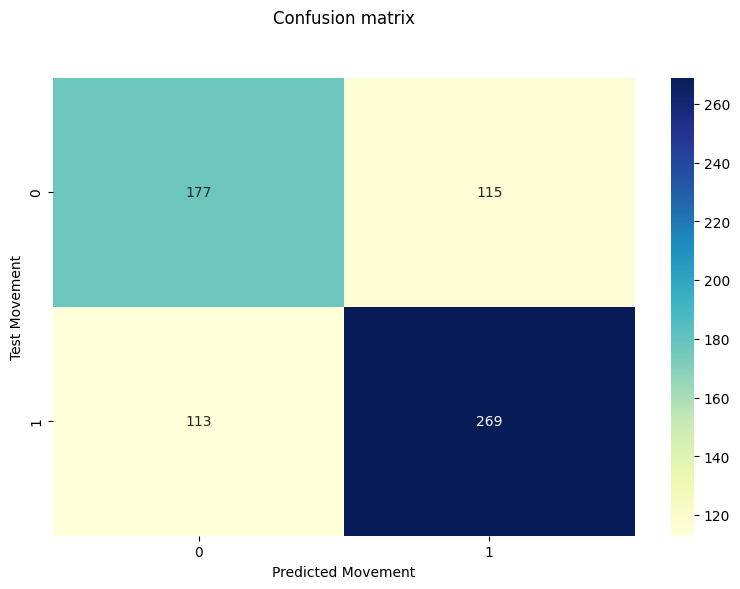

Confusion Matrix:
[[177 115]
 [113 269]]


In [43]:
# Generate the confusion matrix
cnf_matrix = confusion_matrix(lib_pred, i_test)

# Define class names
class_names = ['Not Churned', 'Churned']  # name of classes

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Set tick marks and labels
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')

# Adjust axis labels
ax.xaxis.set_label_position("bottom")

# Add labels and title
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Test Movement')
plt.xlabel('Predicted Movement')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# Print confusion matrix values for reference
print("Confusion Matrix:")
print(cnf_matrix)

# Application of model to all data

In [44]:
features_total=features.copy()


In [45]:
x_total=features_total.drop(columns=['Sales_90','sales_90_flag'])
y_total=features_total['sales_90_flag']
i_total=features_total['Sales_90']
y_pred = logreg_liblinear.predict(x_total)

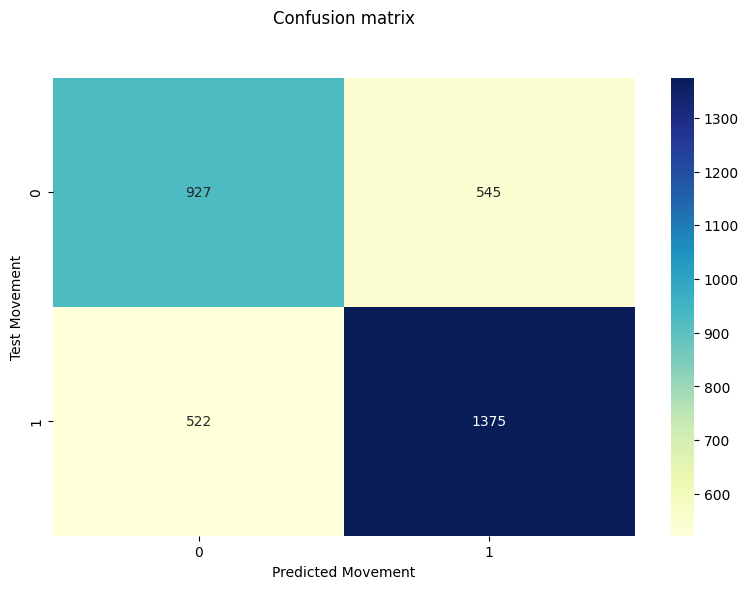

In [46]:
# Generate the confusion matrix
cnf_matrix = confusion_matrix(y_pred, y_total)

# Define class names
class_names = ['Not Churned', 'Churned']  # name of classes

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Set tick marks and labels
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')

# Adjust axis labels
ax.xaxis.set_label_position("bottom")

# Add labels and title
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Test Movement')
plt.xlabel('Predicted Movement')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()


In [47]:
target_names = ['did not spend', 'spend']
print(classification_report(y_total, y_pred, target_names=target_names))


               precision    recall  f1-score   support

did not spend       0.63      0.64      0.63      1449
        spend       0.72      0.72      0.72      1920

     accuracy                           0.68      3369
    macro avg       0.68      0.68      0.68      3369
 weighted avg       0.68      0.68      0.68      3369



In [48]:
features_total=features_total.reset_index()

In [49]:
y_pred=pd.DataFrame(y_pred)
y_pred=y_pred.rename(columns={0:'PREDICTED_SALES'})
features_total=pd.merge(features_total,y_pred,left_index=True, right_index=True)

In [50]:

y_pred = model.predict(x_total)
y_pred=pd.DataFrame(y_pred)
predicted_spend=y_pred.rename(columns={0:'PREDICTED_SPEND'})
features_total=pd.merge(features_total,predicted_spend,left_index=True, right_index=True)
features_total.head()


,CustomerID,Recency,Frequency,sales_value_sum,sales_values_mean,sales_last_month,Sales_90,sales_90_flag,PREDICTED_SALES,PREDICTED_SPEND
0,12347.0,-38,124,2790.86,22.506935,0.0,1519.14,1.0,1.0,1724.900987
1,12348.0,-157,28,1487.24,53.115714,0.0,310.00,1.0,0.0,888.924333
2,12350.0,-219,17,334.40,19.670588,0.0,0.00,0.0,0.0,185.492564
3,12352.0,-171,38,1561.81,41.100263,0.0,944.23,1.0,1.0,953.041110
4,12353.0,-113,4,89.00,22.250000,0.0,0.00,0.0,0.0,108.173326


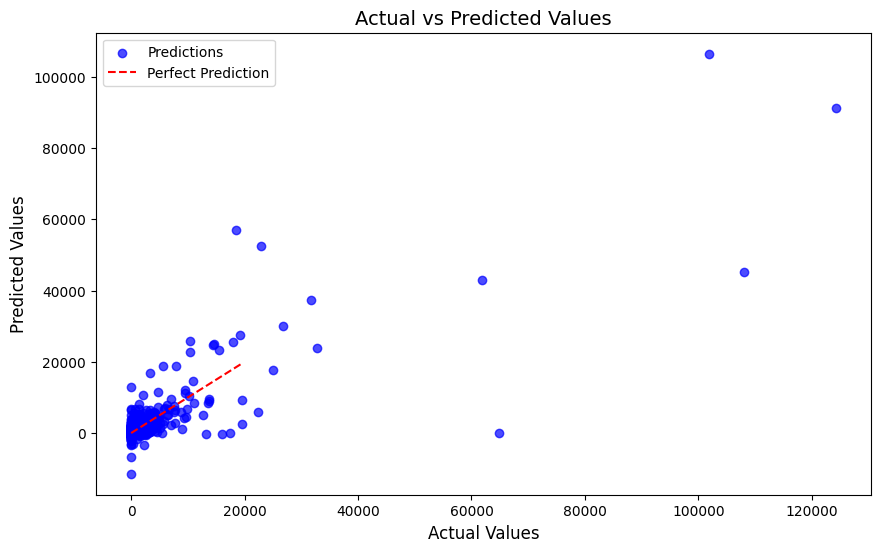

In [51]:
# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(i_total, y_pred, alpha=0.7, color='blue', label='Predictions')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', 
         linestyle='--', 
         label='Perfect Prediction')

# Plot styling
plt.title('Actual vs Predicted Values', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()

# Evaluating benefit of model 

## Business case for targetting of customers
        1. Find biggest customers who are expected to churn 
        2. Calculate the estimated cost of saving promotion- including 

In [52]:
pred_churn_pop=features_total.loc[features_total['PREDICTED_SALES']==0].sort_values(by=['PREDICTED_SPEND'],ascending=False)
pred_churn_pop=pred_churn_pop.loc[features_total['PREDICTED_SPEND']>0]
pred_churn_pop.head()

,CustomerID,Recency,Frequency,sales_value_sum,sales_values_mean,sales_last_month,Sales_90,sales_90_flag,PREDICTED_SALES,PREDICTED_SPEND
1216,14439.0,-228,32,2661.24,83.163750,0.0,0.00,0.0,0.0,1561.265432
2728,17133.0,-99,14,2478.79,177.056429,0.0,2413.45,1.0,0.0,1154.507644
2187,16152.0,-177,29,1829.04,63.070345,0.0,0.00,0.0,0.0,1080.294496
263,12764.0,-225,45,1693.88,37.641778,0.0,0.00,0.0,0.0,1005.898887
1739,15332.0,-275,35,1661.06,47.458857,0.0,0.00,0.0,0.0,940.668824


### Due to the cost of reaching out to customers for a targetted marketting campaign, the campaign will target those with a predicted spend that is higher then the average spend (>200) around 528 customers 

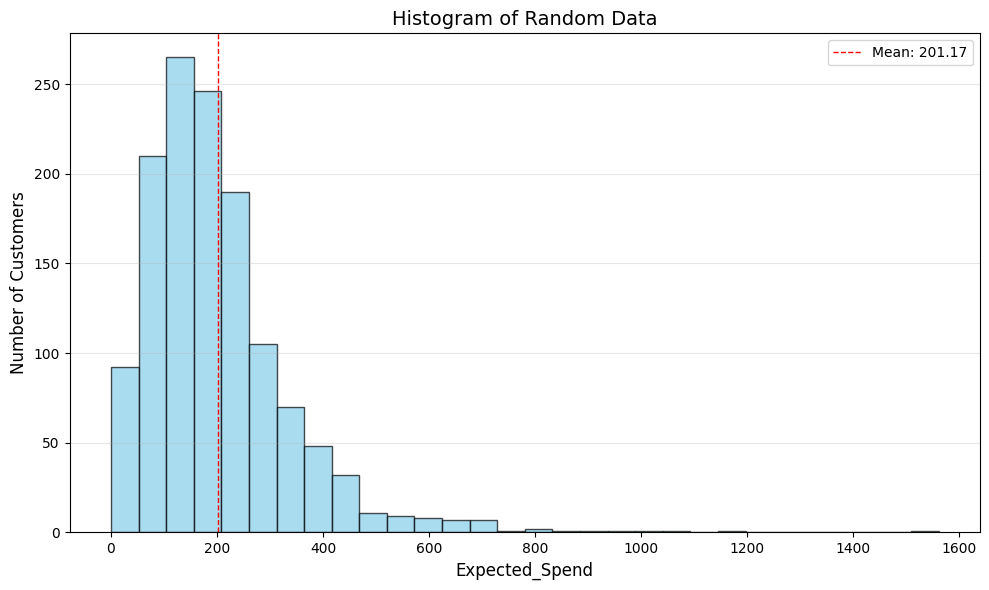

In [53]:
pred_spend=pred_churn_pop['PREDICTED_SPEND']

# Create a figure and axis
plt.figure(figsize=(10, 6))

# Create the histogram
plt.hist(pred_spend, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Expected_Spend', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)

# Add grid for better readability
plt.grid(axis='y', alpha=0.3)

# Add a vertical line at the mean
plt.axvline(pred_spend.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {pred_spend.mean():.2f}')

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

# The Marketing Campaign

The campaign will target customers who are predicted to churn by offering them small but specific discounts (e.g., 6-7%) on their three largest previous purchases. Research indicates that such promotions increase customer repurchase intentions by 21%1 by creating a sense of urgency and encouraging larger order quantities.
These targeted discounts are expected to reduce churn through:

#### > Building customer goodwill
#### > Decreasing intervals between purchases, which reinforces habitual buying behavior

The estimated cost of the marketing program is calculated by multiplying the discount rate by the expected customer spend, totaling $3,248.88. However, two important factors must be considered:

Approximately 34% of predicted churning customers will be misidentified, meaning about one-third of these discounts will be given to customers who would have stayed regardless.

The cost of these discounts should be offset by increased revenue from retained customers and their subsequent repeat purchases. This however will would be impossible to predict therefore this programme should be run on a continual basis to better understand the impacts on customer retention and changing purchasing behaviour.


[^2]:Harvard Business Review, June 7, 2024.  From the article, “Research: Smaller, More Precise Discounts Could Increase Your Sale

In [54]:
contact_churn=pred_churn_pop.loc[pred_churn_pop['PREDICTED_SPEND']>200]

In [55]:
churn_id=contact_churn['CustomerID'].astype(int)
churn_id.head()

1216    14439
2728    17133
2187    16152
263     12764
1739    15332
Name: CustomerID, dtype: int64

In [56]:
trans_churn=transactions.loc[transactions['CustomerID'].isin(churn_id)]

In [57]:
trans_churn=trans_churn[['CustomerID','StockCode','Description','Sales']]
trans_churn=trans_churn.groupby(['CustomerID','StockCode','Description']).agg(sum)

result_alt = (trans_churn.sort_values(['CustomerID','StockCode','Description', 'Sales'], ascending=[True,True,True, False])
               .groupby('CustomerID')
               .head(3)
               .reset_index())

print("\nAlternative method result:")
print(result_alt)

result_alt.head()



Alternative method result:
      CustomerID StockCode                       Description   Sales
0        12348.0     21211    SET OF 72 SKULL PAPER  DOILIES  104.40
1        12348.0     21213       PACK OF 72 SKULL CAKE CASES   63.60
2        12348.0     21725                SWEETIES  STICKERS   40.80
3        12355.0     22423          REGENCY CAKESTAND 3 TIER   25.50
4        12355.0     22649      STRAWBERRY FAIRY CAKE TEAPOT   39.60
...          ...       ...                               ...     ...
1579     18262.0     20971  PINK BLUE FELT CRAFT TRINKET BOX   15.00
1580     18262.0     21213       PACK OF 72 SKULL CAKE CASES   13.20
1581     18287.0     20961           STRAWBERRY BATH SPONGE    37.50
1582     18287.0     20963                 APPLE BATH SPONGE   37.50
1583     18287.0     21014     SWISS CHALET TREE DECORATION    13.92

[1584 rows x 4 columns]


C:\Users\As-Pro\AppData\Local\Temp\ipykernel_15288\820208661.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  trans_churn=trans_churn.groupby(['CustomerID','StockCode','Description']).agg(sum)


,CustomerID,StockCode,Description,Sales
0,12348.0,21211,SET OF 72 SKULL PAPER DOILIES,104.4
1,12348.0,21213,PACK OF 72 SKULL CAKE CASES,63.6
2,12348.0,21725,SWEETIES STICKERS,40.8
3,12355.0,22423,REGENCY CAKESTAND 3 TIER,25.5
4,12355.0,22649,STRAWBERRY FAIRY CAKE TEAPOT,39.6


In [58]:
total_sales=result_alt['Sales'].sum()

# Review and Review

To increase the accuracy of the algorthim if there was an ability to attach more customer data to the transactional data this would allow more accuracy in predicting which customers would churn.

In [59]:
total_sales*.07

np.float64(3248.8764000000006)

# The marketing campaign will offer 

## Predicting Revenue 

## Evaluation of classification ML models
Precision: % of correctly labelled positive instance out of all positive labelled instances TP/TP+FP

Recall: % of correctly labelled positives instances out of all positive instances TP/TP+FN

F1 Score: 2/(1/Precision)+(1/Recall)

AUC: Area under the curb, looks at the difference between the True positive and False positive. 

In [60]:
[^1]: Fader, Peter S., Bruce G. S. Hardie, and Paul D. Berger (2004),
“Customer-Base Analysis with Discrete-Time Transaction Data,”
unpublished working paper.
———, ———, and Ka Lok Lee (2005), “RFM and CLV: Using IsoCLV Curves for Customer Base Analysis,” Journal of Marketing
Research, 42 (November), 415-30




SyntaxError: invalid character '“' (U+201C) (3720704541.py, line 2)